In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("misrakahmed/vegetable-image-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'vegetable-image-dataset' dataset.
Path to dataset files: /kaggle/input/vegetable-image-dataset


In [ ]:
import tensorflow as tf
import zipfile
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

if tf.test.is_built_with_cuda():
    print("TensorFlow is built with CUDA support.")
else:
    print("TensorFlow is NOT built with CUDA support.")

if tf.config.list_physical_devices('GPU'):
    print("A GPU is available.")
    tf.config.experimental.set_memory_growth(tf.config.list_physical_devices('GPU')[0], True)
else:
    print("No GPU available. TensorFlow will run on CPU.")

TensorFlow version: 2.20.0
Num GPUs Available:  1
TensorFlow is built with CUDA support.
A GPU is available.


In [ ]:
# Assuming 'path' from the previous cell holds the dataset directory
dataset_path = '/kaggle/input/vegetable-image-dataset'

# Based on the content of dataset_path, the actual images are within a subdirectory named 'Vegetable Images'.
# The 'train' and 'validation' folders are typically found directly under this 'Vegetable Images' directory.
base_dir = os.path.join(dataset_path, 'Vegetable Images')

# Verify the path before proceeding
if not os.path.exists(base_dir):
    print(f"Error: Base directory '{base_dir}' not found.")
    print("Please check the structure of the '/kaggle/input/vegetable-image-dataset' directory.")
    print("Content of /kaggle/input/vegetable-image-dataset:")
    for item in os.listdir(dataset_path):
        print(item)
    raise FileNotFoundError(f"'{base_dir}' not found.")

print(f"Base directory for image data: {base_dir}")

# Data Augmentation and Preprocessing
IMG_SIZE = (224, 224) # DenseNet121 expects 224x224 input
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # Use 20% of training data for validation
)

# The train and validation data are within subfolders of base_dir (e.g., base_dir/train, base_dir/validation)
train_generator = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'), # Validation data is often taken from the training split for simple splits
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Get number of classes
num_classes = len(train_generator.class_indices)
print(f"Number of classes: {num_classes}")

Base directory for image data: /kaggle/input/vegetable-image-dataset/Vegetable Images
Found 12000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Number of classes: 15


In [ ]:
# Load the DenseNet121 model with pre-trained ImageNet weights, excluding the top classification layer
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Global Average Pooling to reduce dimensions
x = Dense(1024, activation='relu')(x) # A dense layer
predictions = Dense(num_classes, activation='softmax')(x) # Output layer with softmax for multi-class classification

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 8,102,479 (30.91 MB)

 Trainable params: 1,064,975 (4.06 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
EPOCHS = 20 # You can increase this for better performance

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    verbose=1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 311s 750ms/step - accuracy: 0.9584 - loss: 0.1403 - val_accuracy: 0.9803 - val_loss: 0.0687
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 206s 550ms/step - accuracy: 0.9868 - loss: 0.0413 - val_accuracy: 0.9937 - val_loss: 0.0257
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 252s 671ms/step - accuracy: 0.9921 - loss: 0.0233 - val_accuracy: 0.9890 - val_loss: 0.0436
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 207s 552ms/step - accuracy: 0.9885 - loss: 0.0388 - val_accuracy: 0.9837 - val_loss: 0.0464
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 198s 528ms/step - accuracy: 0.9928 - loss: 0.0247 - val_accuracy: 0.9860 - val_loss: 0.0476
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 197s 524ms/step - accuracy: 0.9903 - loss: 0.0308 - val_accuracy: 0.9920 - val_loss: 0.0234
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 196s 523ms/step - accuracy: 0.9929 - loss: 0.0206 - val_accuracy: 0.9913 - val_loss: 0.0306
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 197s 524ms/step - accuracy: 0.9933 -

In [ ]:
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

Final Training Accuracy: 0.9953
Final Validation Accuracy: 0.9947
Final Training Loss: 0.0146
Final Validation Loss: 0.0232


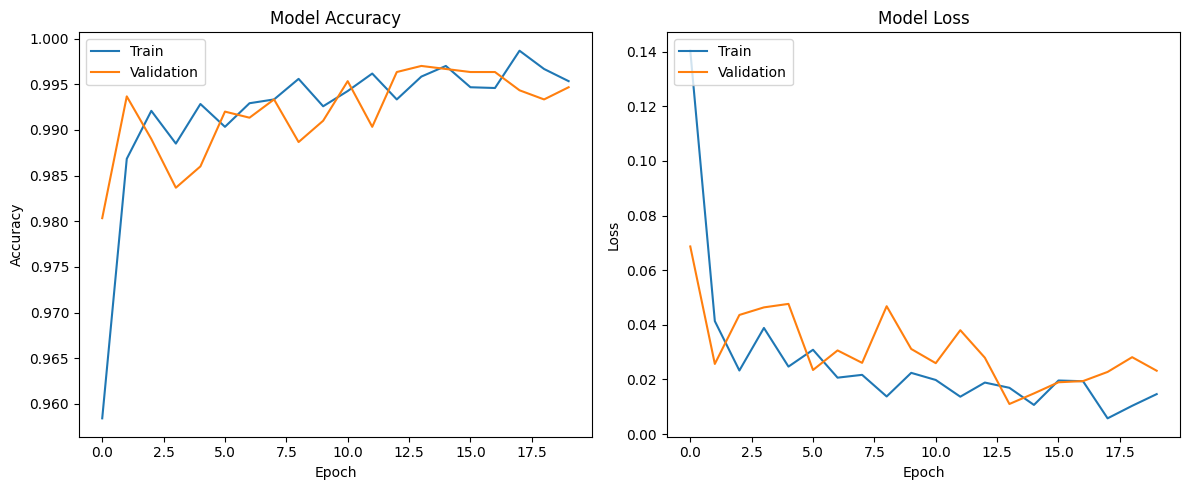

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()